In [ ]:
from pathlib import Path
import sys
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from experiment.full_cumulative_fidelity import run_cap_convergence

# Figure style from calibration_twophoton_waveguideQED, editable here.
colors = ['#003f5c', '#8e3e7a', '#ed9a00', '#2a4a79', '#c64f8b']
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.linewidth': 0.7,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'axes.prop_cycle': plt.cycler(color=colors),
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'figure.dpi': 300,
})
pd.set_option('display.float_format', '{:.9g}'.format)


# Convergence with the total photon cap

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is `sqrt`, as in Uri's experiments.
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).


## Parameters


In [ ]:
CTRL_M_EXPLICIT = True
M = 5                         # Must be odd; k=0 is included.
cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 2.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 
              'D': 0.2, 
              'L': 2*np.pi,
              'x_tls': 0.0, 
              'coupling': 'sqrt', 
              'initial_state': 'g'}

param_photon = {'k_0': 1.0, 
                'sigma_k': 0.4, 
                'x_0': -2.0,
                'state': 'number', 
                'n': 1, 
                'alpha': 1.0}

param_time_evol = {'T': 4.0, 'dt': 0.05, 'rtol': 1e-9, 'atol': 1e-11}
n_max = 2
truncation = 'full+totalcap'
RWA = False

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, truncation=truncation, RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)


## Resource estimate

Informative only: the estimate does not stop execution. Memory covers retained complex vectors and excludes sparse matrices, Python objects and solver workspace.

In [3]:
caps = (1, 2, 3, 4)
config = replace(config, param_photon={**param_photon, 'state': 'coherent', 'alpha': 1.0})
estimate = estimate_config(replace(config, n_max=max(caps), store_state=False))
display(estimate)

Value
Group  Parameter                          
Cavity omega_0                           1
       D                               0.2
       L                        6.28318531
       x_tls                             0
       coupling                       sqrt
       initial_state                     g
Modes  M                                 5
       delta_k                           1
       k_min                            -2
       k_max                             2
       IR_effective                      0
       UV_effective                      2
Time   T                                 4
       dt                             0.05
       rtol                          1e-09
       atol                          1e-11
       n_outputs                        81
Memory basis                 full+totalcap
       n_max                             4
       dimension                       252
       store_state                   False
       ket_GiB              3.75509262e-06
       history_GiB          3.75509262e-06
       retained_vectors_GiB 7.51018524e-06

## Data generation

The associated Python module only generates numerical data.

In [4]:
results = run_cap_convergence(config, caps)

## Postprocessing

Prepare the arrays and DataFrames used by the plots below.

In [5]:
fidelity_table = pd.DataFrame({
    f'{name}_{stage}': results[f'{name}_initial'] if stage == 'initial' else results[name]
    for name in ('F_state', 'F_atom') for stage in ('initial', 'final')
}, index=pd.MultiIndex.from_arrays(
    [results['caps'][:-1], results['caps'][1:]], names=['lower_cap', 'upper_cap']))
display(fidelity_table)

,,F_state_initial,F_state_final,F_atom_initial,F_atom_final
lower_cap,upper_cap,,,,
1,2,0.8,0.801356379,1,0.98774525
2,3,0.9375,0.939892982,1,0.997867561
3,4,0.984615385,0.985832999,1,0.999812792


## Plots

All drawing code is visible and editable here.

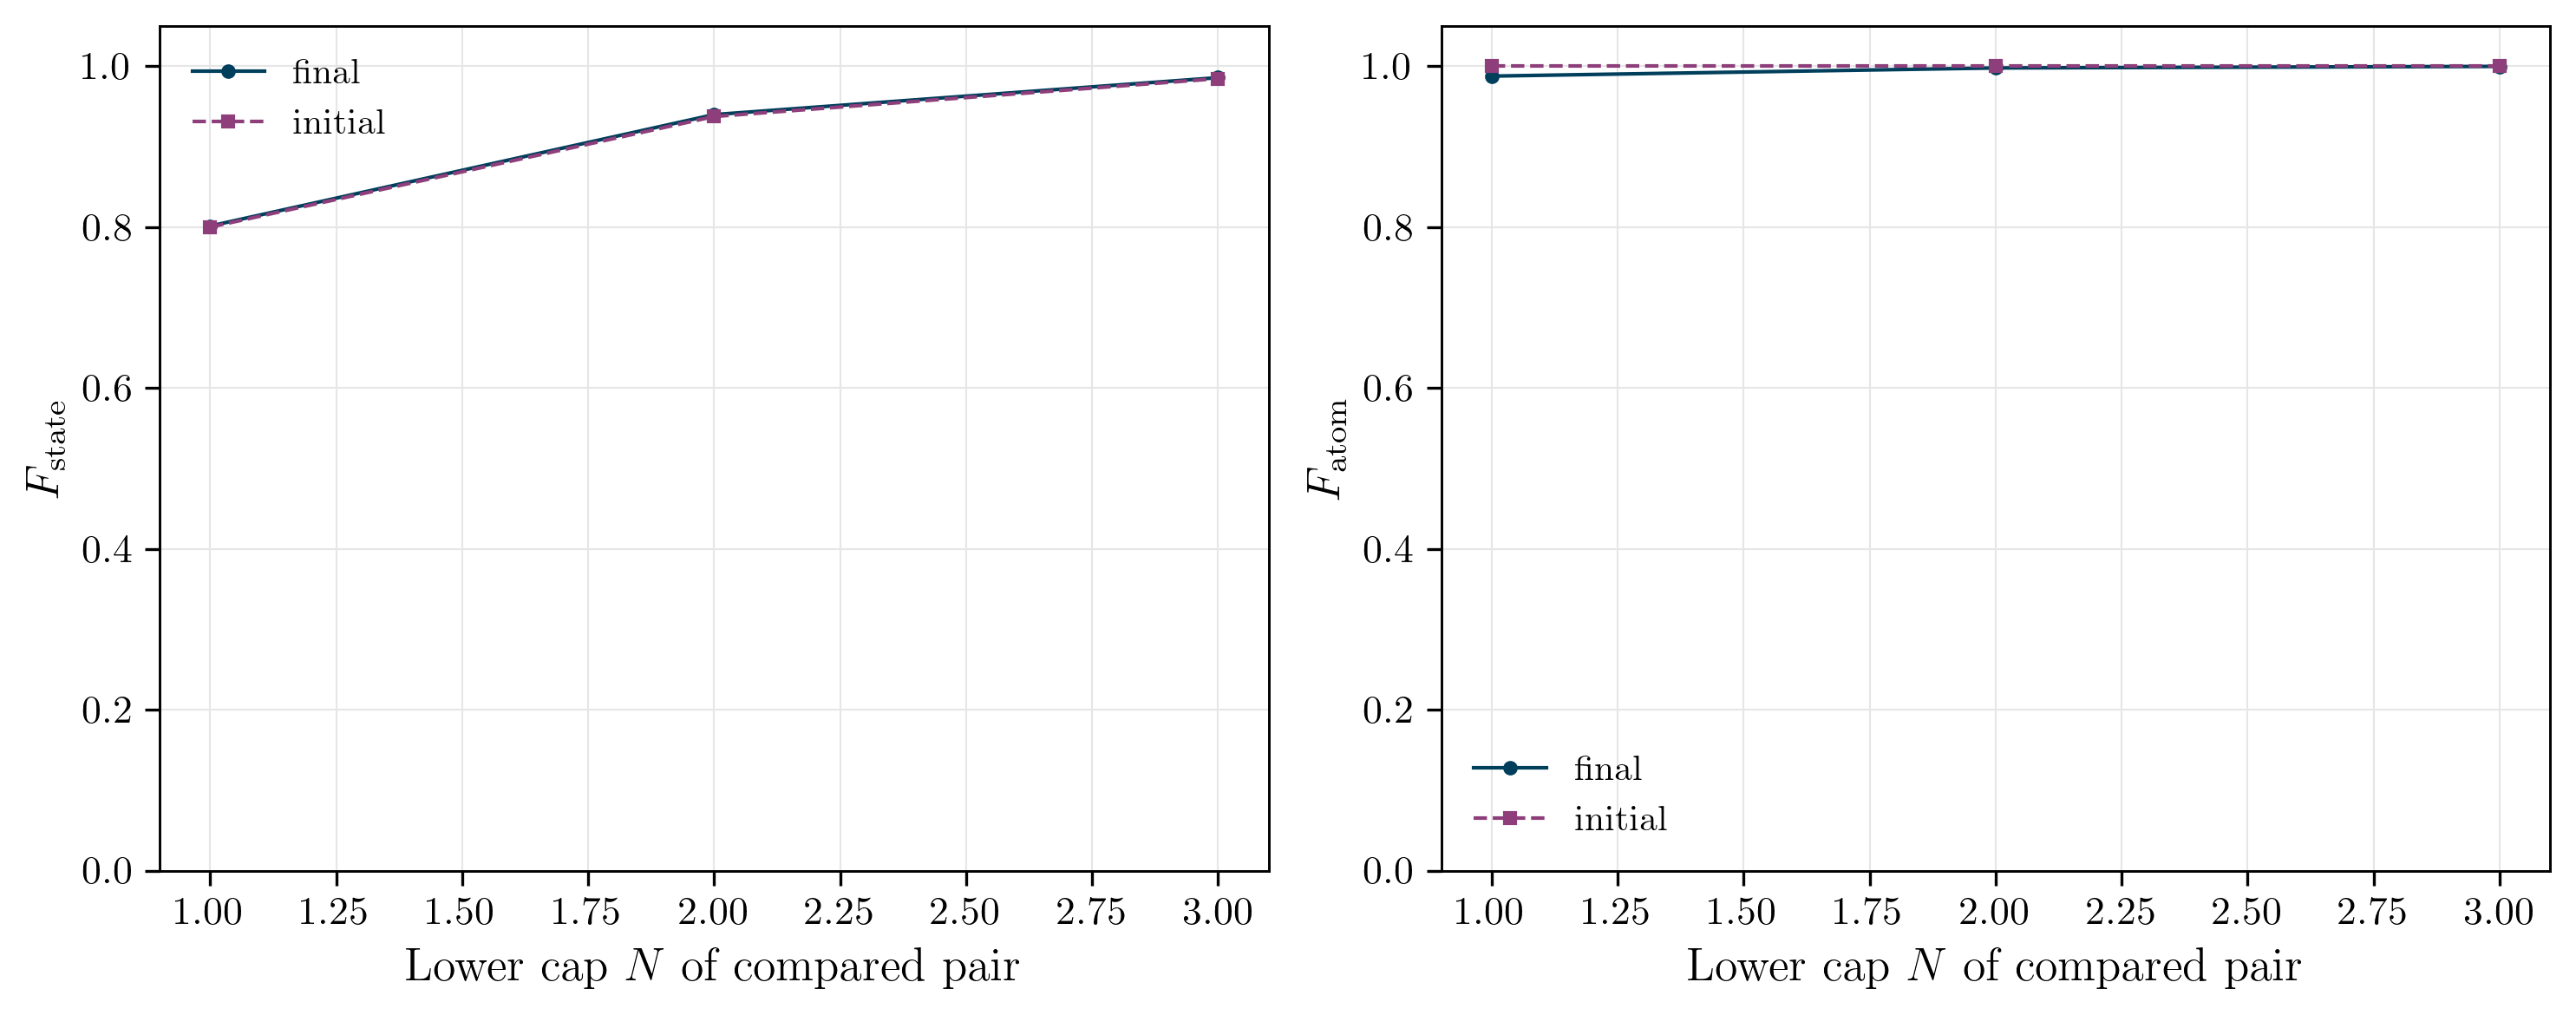

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, label in zip(axes, ('F_state', 'F_atom'), (r'$F_{\mathrm{state}}$', r'$F_{\mathrm{atom}}$')):
    ax.plot(results['caps'][:-1], results[name], 'o-', label='final')
    ax.plot(results['caps'][:-1], results[f'{name}_initial'], 's--', label='initial')
    ax.set(xlabel=r'Lower cap $N$ of compared pair', ylabel=label, ylim=(0, 1.05))
    ax.legend()
for ax in axes.flat:
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)
    ax.tick_params(length=4, width=0.8)
fig.tight_layout()
plt.show()